In [30]:
import pandas as pd
import numpy as np

In [31]:

df = pd.read_csv("data/processed/flood_rainfall_features_2022.csv")

In [32]:
print(df.shape)
print(df.columns.tolist())
print(df.describe)
print(df.isnull().sum())


(267364, 10)
['State', 'District', 'month', 'Day', 'Rainfall', 'Date', 'flood_occurred', 'rainfall_3day', 'rainfall_7day', 'historical_flood_count_10yr']
<bound method NDFrame.describe of                     State        District  month  Day  Rainfall        Date  \
0       andaman & nicobar         nicobar     10    1       0.0  2022-10-01   
1       andaman & nicobar         nicobar     10    2       0.0  2022-10-02   
2       andaman & nicobar         nicobar     10    3       0.0  2022-10-03   
3       andaman & nicobar         nicobar     10    4       0.0  2022-10-04   
4       andaman & nicobar         nicobar     10    5       0.0  2022-10-05   
...                   ...             ...    ...  ...       ...         ...   
267359        west bengal  uttar dinajpur     10   27       0.0  2022-10-27   
267360        west bengal  uttar dinajpur     10   28       0.0  2022-10-28   
267361        west bengal  uttar dinajpur     10   29       0.0  2022-10-29   
267362        west ben

In [33]:
print(df["flood_occurred"].value_counts())

flood_occurred
0    266382
1       982
Name: count, dtype: int64


In [34]:
print(df["flood_occurred"].value_counts(normalize=True) * 100)

flood_occurred
0    99.63271
1     0.36729
Name: proportion, dtype: float64


In [35]:
print(df.isnull().sum())

State                              0
District                           0
month                              0
Day                                0
Rainfall                           0
Date                               0
flood_occurred                     0
rainfall_3day                      0
rainfall_7day                      0
historical_flood_count_10yr    70056
dtype: int64


In [36]:
print(df.groupby("month")["flood_occurred"].agg(["count", "sum"]))

       count  sum
month            
1      22692   24
2      20496    0
3      22692    9
4      21960   11
5      22692  185
6      21960  183
7      22692  238
8      22754  127
9      21990  113
10     22723   87
11     21990    5
12     22723    0


In [37]:
print(df[df["flood_occurred"] == 1]["month"].value_counts().sort_index())

month
1      24
3       9
4      11
5     185
6     183
7     238
8     127
9     113
10     87
11      5
Name: count, dtype: int64


In [38]:
print(
    df[df["flood_occurred"] == 1][
        ["State", "District", "Date", "Rainfall", 
         "rainfall_3day", "rainfall_7day"]
    ].head(20)
)

                  State       District        Date   Rainfall  rainfall_3day  \
2006     andhra pradesh  east godavari  2022-07-01   8.688540      15.245620   
2313     andhra pradesh         guntur  2022-05-04   4.533670       5.345111   
3118     andhra pradesh        kurnool  2022-07-18   4.413170       8.010221   
4270     andhra pradesh     srikakulam  2022-09-13  11.547800      50.724130   
5308     andhra pradesh  west godavari  2022-07-18  33.630200      54.106914   
5969  arunachal pradesh          anjaw  2022-05-10   0.155335       0.155335   
5972  arunachal pradesh          anjaw  2022-05-13  11.972500      22.209435   
5985  arunachal pradesh          anjaw  2022-05-26   4.921560      10.695020   
6337  arunachal pradesh      changlang  2022-05-13  11.972300      28.340380   
6348  arunachal pradesh      changlang  2022-05-24   0.000000       5.761744   
6852  arunachal pradesh  dibang valley  2022-10-10  92.528900     139.317400   
7148  arunachal pradesh    east kameng  

In [39]:
df.groupby("flood_occurred")[
    ["Rainfall", "rainfall_3day", "rainfall_7day",
     "historical_flood_count_10yr"]
].mean()

,Rainfall,rainfall_3day,rainfall_7day,historical_flood_count_10yr
flood_occurred,,,,
0,3.570180,10.760087,25.212771,8.600420
1,28.976785,73.490200,140.656266,16.754045


In [40]:
df.groupby("flood_occurred")[
    ["Rainfall", "rainfall_3day", "rainfall_7day",
     "historical_flood_count_10yr"]
].median()

,Rainfall,rainfall_3day,rainfall_7day,historical_flood_count_10yr
flood_occurred,,,,
0,0.0000,0.153545,2.927803,5.0
1,17.0242,48.259370,98.507768,13.0


In [41]:
df[df["flood_occurred"] == 1][
    ["Rainfall", "rainfall_3day", "rainfall_7day",
     "historical_flood_count_10yr"]
].describe()

,Rainfall,rainfall_3day,rainfall_7day,historical_flood_count_10yr
count,982.000000,982.000000,982.000000,927.000000
mean,28.976785,73.490200,140.656266,16.754045
std,38.898515,90.506196,148.201659,14.964823
min,0.000000,0.000000,0.000000,1.000000
25%,4.940647,17.451158,45.579338,5.000000
50%,17.024200,48.259370,98.507768,13.000000
75%,37.682050,95.781625,184.508768,24.000000
max,575.089000,1295.003200,1902.393000,107.000000


In [42]:
missing_history = df[df["historical_flood_count_10yr"].isna()]

print("Rows with missing historical flood count:", len(missing_history))
print("Unique states:", missing_history["State"].nunique())
print("Unique districts:", missing_history["District"].nunique())

Rows with missing historical flood count: 70056
Unique states: 36
Unique districts: 305


In [43]:
missing_history = df[
    df["historical_flood_count_10yr"].isna()
]

print(
    missing_history[
        ["State", "District"]
    ]
    .drop_duplicates()
    .head(100)
)

                   State                  District
0      andaman & nicobar                   nicobar
31     andaman & nicobar                  nicobars
365    andaman & nicobar    north & middle andaman
396    andaman & nicobar  north and middle andaman
730    andaman & nicobar             south andaman
...                  ...                       ...
88299    jammu & kashmir                     riasi
88330    jammu & kashmir                     samba
89029    jammu & kashmir                  shupiyan
91250          jharkhand                     dumka
91615          jharkhand            east singhbhum

[100 rows x 2 columns]


In [44]:

missing_pairs = (
    df[df["historical_flood_count_10yr"].isna()]
    [["State", "District"]]
    .drop_duplicates()
)

print("Unique missing State-District pairs:", len(missing_pairs))

Unique missing State-District pairs: 309


In [45]:
import os

print(os.listdir("data"))

['DFSI.csv', 'District_FloodedArea.csv', 'District_FloodImpact.csv', 'flood_inventory.csv', 'processed', 'rainfall.csv']


In [46]:
print(os.listdir("data/processed"))

['flood_rainfall_2022.csv', 'flood_rainfall_features_2022.csv']


In [47]:
df1 = pd.read_csv("data/processed/flood_rainfall_2022.csv")

print(df1.shape)
print(df1.columns.tolist())

(267364, 7)
['State', 'District', 'month', 'Day', 'Rainfall', 'Date', 'flood_occurred']


In [48]:
print(df1.head())

               State                  District  month  Day   Rainfall  \
0  andaman & nicobar                  nicobars      1    1   0.000000   
1  andaman & nicobar  north and middle andaman      1    1   0.000000   
2  andaman & nicobar            south andamans      1    1   0.000000   
3     andhra pradesh                 anantapur      1    1   0.379965   
4     andhra pradesh                  chittoor      1    1  14.144900   

         Date  flood_occurred  
0  2022-01-01               0  
1  2022-01-01               0  
2  2022-01-01               0  
3  2022-01-01               0  
4  2022-01-01               0  


In [49]:
print(
    df.groupby("flood_occurred")["historical_flood_count_10yr"]
    .apply(lambda x: x.isna().sum())
)

flood_occurred
0    70001
1       55
Name: historical_flood_count_10yr, dtype: int64


In [50]:
df["historical_flood_count_missing"] = (
    df["historical_flood_count_10yr"].isna().astype(int)
)

df["historical_flood_count_10yr"] = (
    df["historical_flood_count_10yr"].fillna(0)
)

In [51]:
print(df["historical_flood_count_10yr"].isna().sum())
print(df["historical_flood_count_missing"].value_counts())

0
historical_flood_count_missing
0    197308
1     70056
Name: count, dtype: int64


In [52]:
X = df[
    [
        "State",
        "District",
        "month",
        "Day",
        "Rainfall",
        "rainfall_3day",
        "rainfall_7day",
        "historical_flood_count_10yr",
        "historical_flood_count_missing"
    ]
]

y = df["flood_occurred"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (267364, 9)
y shape: (267364,)


## 7. Feature and Target Selection

In [55]:
print(X.dtypes)

State                                 str
District                              str
month                               int64
Day                                 int64
Rainfall                          float64
rainfall_3day                     float64
rainfall_7day                     float64
historical_flood_count_10yr       float64
historical_flood_count_missing      int64
dtype: object


## 8. Train-Test Split

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (213891, 9)
X_test: (53473, 9)
y_train: (213891,)
y_test: (53473,)


## 9. Feature Preprocessing

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["State", "District"]

numeric_features = [
    "month",
    "Day",
    "Rainfall",
    "rainfall_3day",
    "rainfall_7day",
    "historical_flood_count_10yr",
    "historical_flood_count_missing"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


## 10. Baseline Model — Logistic Regression

In [58]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Baseline model created successfully.")

Baseline model created successfully.


## 11. Model Training

In [59]:
baseline_model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


C:\Users\joysh\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [60]:
y_pred = baseline_model.predict(X_test)

print(pd.Series(y_pred).value_counts())

0    46426
1     7047
Name: count, dtype: int64


In [61]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0     0.9989    0.8704    0.9302     53277
           1     0.0204    0.7347    0.0398       196

    accuracy                         0.8699     53473
   macro avg     0.5097    0.8026    0.4850     53473
weighted avg     0.9953    0.8699    0.9270     53473


Confusion Matrix:
[[46374  6903]
 [   52   144]]


In [62]:
y_prob = baseline_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8923274698696416


C:\Users\joysh\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


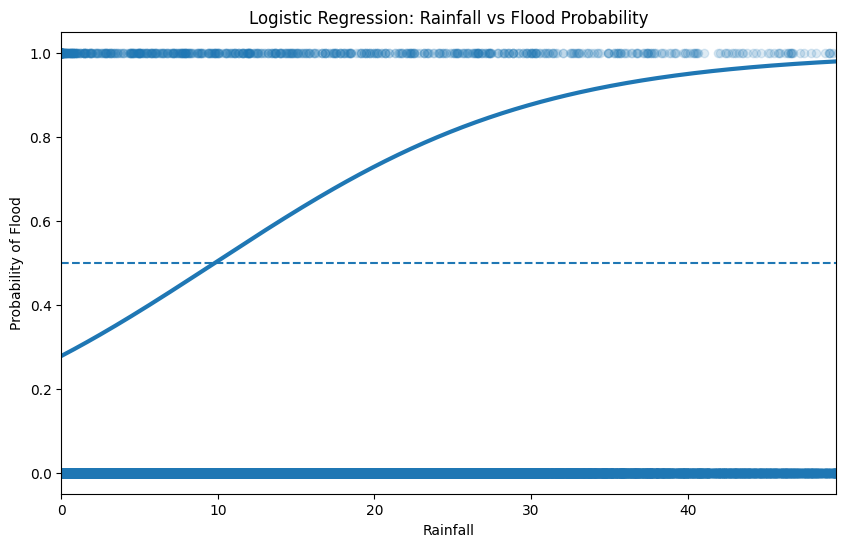

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Use only Rainfall for this visualization
X_rain = df[["Rainfall"]]
y_rain = df["flood_occurred"]

# Train a simple Logistic Regression model
lr_visual = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

lr_visual.fit(X_rain, y_rain)

# Create rainfall values for smooth curve
rainfall_range = np.linspace(
    df["Rainfall"].min(),
    df["Rainfall"].quantile(0.99),
    300
).reshape(-1, 1)

# Predict probability of flood
probability = lr_visual.predict_proba(rainfall_range)[:, 1]

# Plot
plt.figure(figsize=(10, 6))

# Actual data points
plt.scatter(
    df["Rainfall"],
    df["flood_occurred"],
    alpha=0.15
)

# Logistic Regression curve
plt.plot(
    rainfall_range,
    probability,
    linewidth=3
)

# Decision boundary
plt.axhline(
    0.5,
    linestyle="--"
)

plt.xlabel("Rainfall")
plt.ylabel("Probability of Flood")
plt.title("Logistic Regression: Rainfall vs Flood Probability")

plt.ylim(-0.05, 1.05)
plt.xlim(0, df["Rainfall"].quantile(0.99))

plt.show()